Importing Libraries

In [222]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error,root_mean_squared_error


Load the Dataset and Printing first five rows

In [223]:
df = pd.read_csv("insurance.csv")
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


Printing Number of Rows and Columns

In [224]:
print(df.shape)

(1338, 7)


Describing the dataset

In [225]:
print(df.describe())

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


Datasets Information


In [226]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None


Checking the null values.

In [227]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


Checking Duplicate Values

In [228]:
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 1


In [229]:
df = df.drop_duplicates()

In [230]:
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 0


Checking Outliers

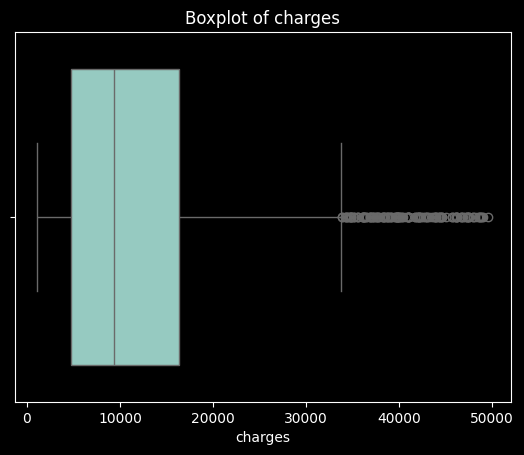

In [246]:
sns.boxplot(x=df["charges"])
plt.title("Boxplot of charges")
plt.show()


Based on the boxplot above, charges exceeding $50,000 are rare and act as outliers. 

In [247]:
df = df[df['charges'] < 50000]


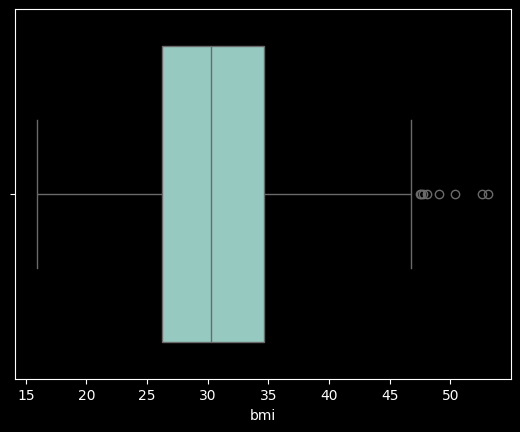

In [248]:
sns.boxplot(x=df["bmi"])
plt.show()

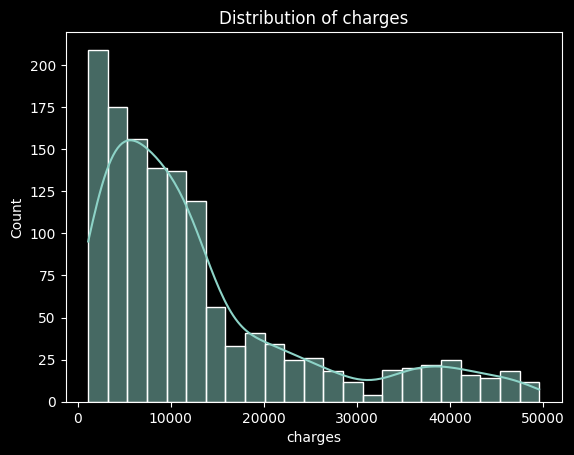

In [250]:
sns.histplot(df["charges"],kde=True) #Kde = Kernal Density Estimation
plt.title("Distribution of charges")
plt.show()

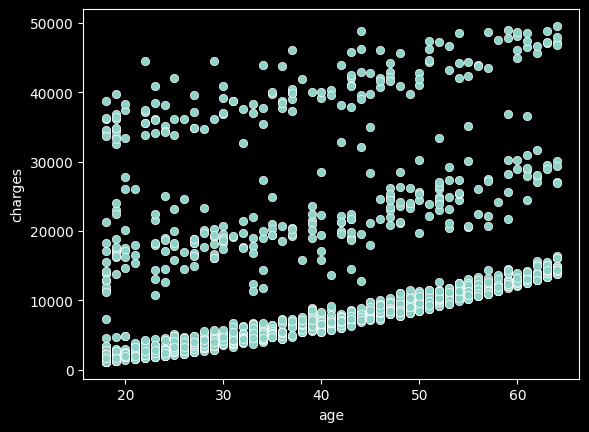

In [251]:
sns.scatterplot(x="age", y="charges",data=df)
plt.show()

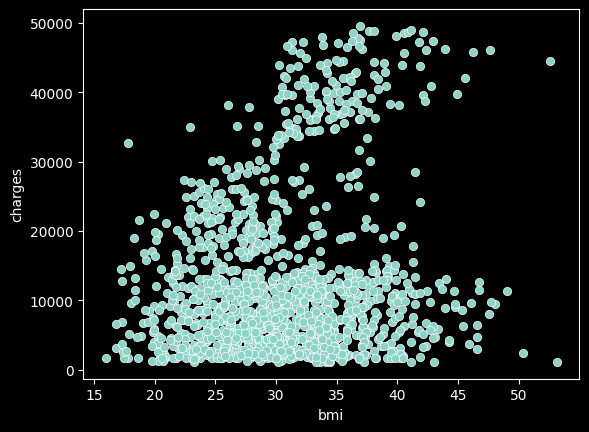

In [252]:
sns.scatterplot(x="bmi", y="charges",data=df)
plt.show()

Convert Categorical Variable into Numerical Variables

In [253]:
df = pd.get_dummies(df,drop_first=True)

In [254]:
df['bmi_smoker'] = df['bmi'] * df['smoker_yes']

In [255]:
X = df.drop("charges",axis=1)
Y = df["charges"]

In [256]:
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.3,random_state=42)



In [257]:
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [258]:
coef_df = pd.DataFrame(model.coef_,X.columns,columns=["Coefficient"])
print(coef_df)

                   Coefficient
age                 274.520047
bmi                  33.123918
children            658.028896
sex_male           -564.762713
smoker_yes       -20390.039844
region_northwest   -472.877596
region_southeast  -1058.561638
region_southwest  -1351.804271
bmi_smoker         1429.141741


In [259]:
y_pred = model.predict(X_test)
print(y_pred)

[ 2153.38507466 12860.91472241 11098.36103825  8569.20045737
 14348.49651271 28798.99165429 42984.36472654  3744.27038291
 14627.41142761  3087.91392358 26566.41656767 12604.44566451
  4811.41830301  3058.4173529   2255.50637151  7137.0820867
 10534.99505379  8479.87079595 12149.76642884 15515.34356816
  2182.06320071 11003.2565974   1332.73252397 26342.23706943
  7821.77056468  7987.44495987  8390.34270154  6669.68891049
 13335.42958401 22987.2988249  49694.28982709  6799.39481254
  9572.12681545  3767.0484525   2084.15608625  7738.59610756
 32956.39475247 34668.86260871  3114.16487573 49100.64255058
 13788.38791886  1586.64962151  8811.39121825 29408.8397177
 12802.20045263  7462.82817771 13383.49242703  3983.42507016
 27321.2645892   7926.52092222  1897.60597827 13973.47908172
 14241.37476473 17421.86800752 27376.83899182  2584.51871569
 19951.54953985  2919.84847608 11354.57467378  6857.23439761
 12995.37359667  8370.45112527  8032.79377766  6411.54097035
  8720.93201569 10495.2592

In [260]:
print("Mean Squared Error:",mean_squared_error(y_test,y_pred))
print("Mean Absolute Error:",mean_absolute_error(y_test,y_pred))
print("Root Mean Squared Error:",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2 Score:",r2_score(y_test,y_pred))

r2 = r2_score(y_test, y_pred)
# Display as Percentage
print(f"Model Accuracy (R2 Score): {r2 * 100:.2f}%")

Mean Squared Error: 20257564.450836778
Mean Absolute Error: 2750.441030200401
Root Mean Squared Error: 4500.840416059736
R2 Score: 0.8528913257496386
Model Accuracy (R2 Score): 85.29%


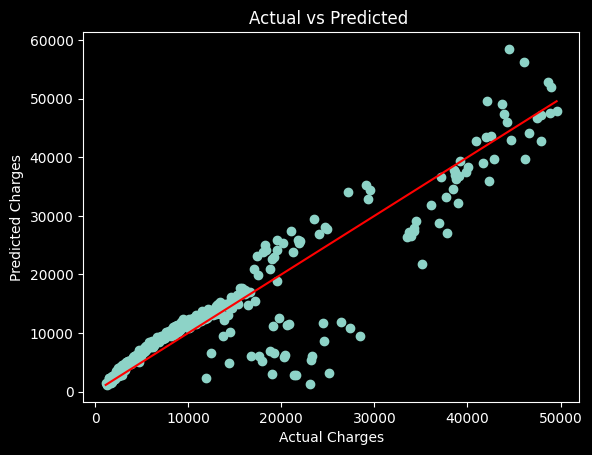

In [264]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted ")
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],color="red")
plt.show()

In [263]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
results.head(10)


,Actual,Predicted
0,1634.57340,2153.385075
1,11381.32540,12860.914722
2,9861.02500,11098.361038
3,6455.86265,8569.200457
4,14711.74380,14348.496513
5,36898.73308,28798.991654
6,44641.19740,42984.364727
7,2731.91220,3744.270383
8,14256.19280,14627.411428
9,18955.22017,3087.913924
